# Classifier Masks Compare

`services/forest_mask/classifier.py` の `classify_forest_status` が返す 3 種類のマスクを比較する。

- **healthy** : 正常 (ExG > th & S > sat_th & Lab a < lab_a_th)
- **anomaly** : 異常 (S < anomaly_sat_th & V > anomaly_val_th & texture > texture_th)
- **unknown** : 上記いずれにも該当しない

入力: `data/input/jpg/sample/sample_tree.jpg`

In [1]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [2]:
# モジュールリロードを有効化（実装変更を即反映するため）
%load_ext autoreload
%autoreload 2

In [3]:
# パラメータ (CLI のデフォルトに合わせる)
INPUT_PATH = Path("data/input/jpg/sample/sample_tree.jpg")

EXG_THRESHOLD = 10.0
SAT_TH = 80.0
LAB_A_TH = 125.0
ANOMALY_SAT_TH = 60.0
ANOMALY_VAL_TH = 170.0
TEXTURE_KERNEL = 5
TEXTURE_TH = 5.0

In [4]:
# 特徴量計算 & 分類
from services.common.image import load_rgb
from services.forest_mask.exg import calc_exg
from services.forest_mask.color import calc_hsv, calc_lab
from services.forest_mask.texture import calc_texture
from services.forest_mask.classifier import classify_forest_status

rgb = load_rgb(INPUT_PATH)
exg = calc_exg(rgb)
hsv_h, hsv_s, hsv_v = calc_hsv(rgb)
lab_l, lab_a, lab_b = calc_lab(rgb)
texture = calc_texture(exg, TEXTURE_KERNEL)

healthy_mask, anomaly_mask, unknown_mask = classify_forest_status(
    exg=exg,
    s=hsv_s,
    v=hsv_v,
    lab_a=lab_a,
    texture=texture,
    exg_threshold=EXG_THRESHOLD,
    saturation_threshold=SAT_TH,
    lab_a_threshold=LAB_A_TH,
    anomaly_saturation_threshold=ANOMALY_SAT_TH,
    anomaly_value_threshold=ANOMALY_VAL_TH,
    texture_threshold=TEXTURE_TH,
)

total = rgb.shape[0] * rgb.shape[1]
for name, m in [("healthy", healthy_mask), ("anomaly", anomaly_mask), ("unknown", unknown_mask)]:
    pix = int(m.sum())
    print(f"{name:8s}: {pix:>10d} px  ({pix / total * 100:5.2f}%)")

healthy :     450393 px  (14.34%)
anomaly :     286567 px  ( 9.12%)
unknown :    2404672 px  (76.54%)


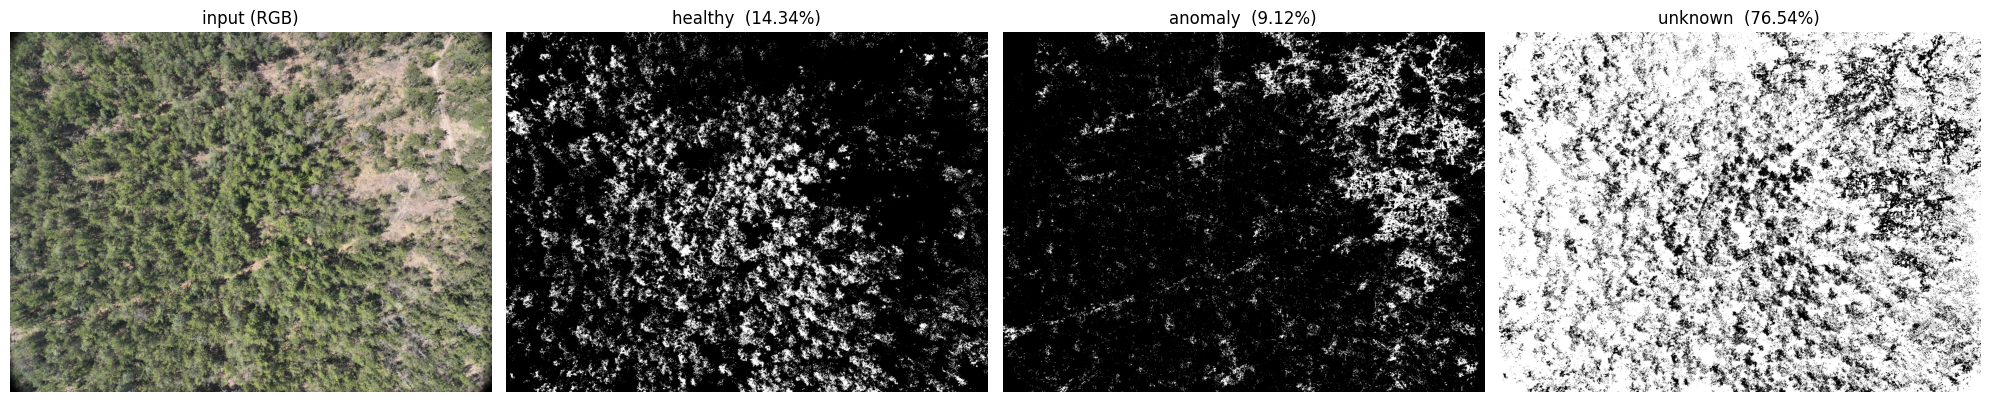

In [5]:
# 3 つのマスクを横並びで比較
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")

for ax, mask, name in [
    (axes[1], healthy_mask, "healthy"),
    (axes[2], anomaly_mask, "anomaly"),
    (axes[3], unknown_mask, "unknown"),
]:
    ax.imshow(mask, cmap="gray", vmin=0, vmax=1)
    pix = int(mask.sum())
    ax.set_title(f"{name}  ({pix / total * 100:.2f}%)")
    ax.axis("off")

plt.tight_layout()
plt.show()

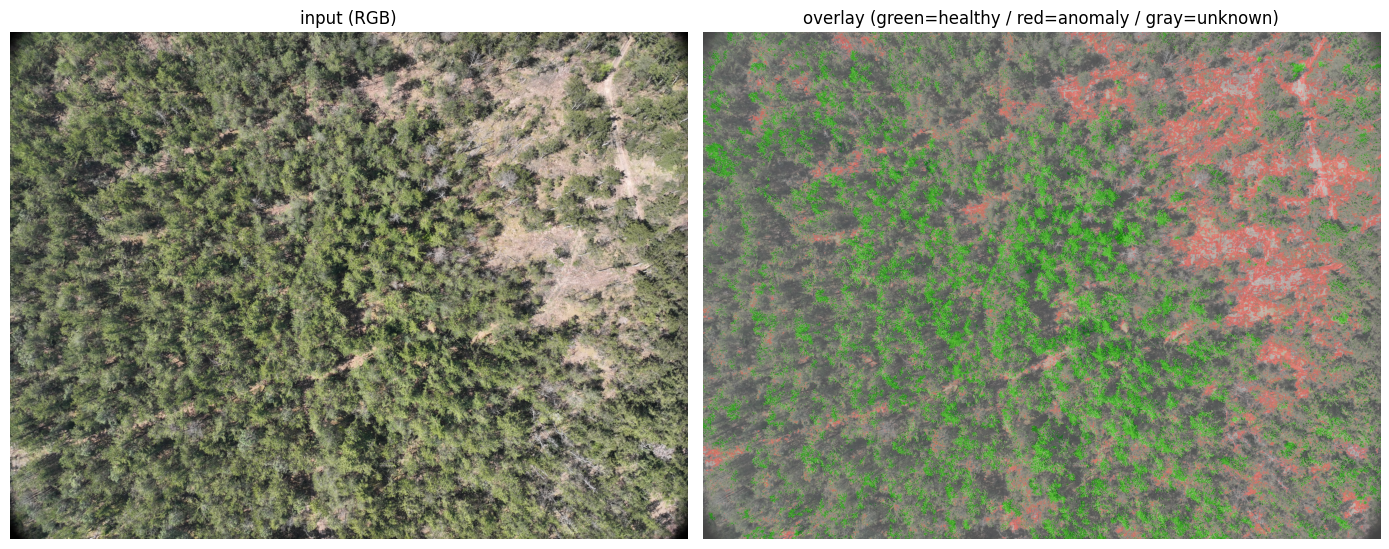

In [6]:
# 入力に色分けオーバーレイ
#   healthy = 緑 / anomaly = 赤 / unknown = 灰
import numpy as np

ALPHA = 0.45

overlay = rgb.astype(np.float32).copy()
colors = {
    "healthy": (np.array([0, 200, 0], dtype=np.float32), healthy_mask),
    "anomaly": (np.array([220, 30, 30], dtype=np.float32), anomaly_mask),
    "unknown": (np.array([150, 150, 150], dtype=np.float32), unknown_mask),
}
for color, mask in colors.values():
    overlay[mask] = (1 - ALPHA) * overlay[mask] + ALPHA * color
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title("overlay (green=healthy / red=anomaly / gray=unknown)")
axes[1].axis("off")
plt.tight_layout()
plt.show()